In [70]:
import numpy as np
import pylab as plt
from scipy.interpolate import LinearNDInterpolator
from matplotlib.colors import LogNorm

from astropy import units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, Galactic, EarthLocation, AltAz
from astropy_healpix import HEALPix

import healpy as hp

In [71]:
NFREQ = 6

dB = lambda x: 10*np.log10(x)
un_dB = lambda x: 10**(x/10)

def load_uan(fname):
    """
    Load antenna pattern data from a UAN text file. Returns the power values.
    """
    def strip_header(f):
        # Parse and strip header lines from input file
        phi_inc = theta_inc = magnitude = None    # need these to process the file
        line = f.readline()
        while "end_<parameters>" not in line:
            if "phi_inc" in line:
                phi_inc = int(line.split()[1])
            if "theta_inc" in line:
                theta_inc = int(line.split()[1])
            if "magnitude" in line:
                magnitude_unit = line.split()[1]
            if "frequencyHz" in line:
                freq_hz = float(line.split()[1])
            line = f.readline()

        # Check headers were found
        assert  phi_inc is not None \
            and theta_inc is not None \
            and magnitude_unit is not None \
            and freq_hz is not None, \
            "Required headers missing"
        return phi_inc, theta_inc, magnitude_unit, freq_hz

    def polar_to_re_im(fn, amp, phase):
        # amp in dB and phase in degrees
        return fn(amp) * (np.cos(np.deg2rad(phase)) + 1.j*np.sin(np.deg2rad(phase)))
    
    # Helper conversion functions
    no_change = lambda vals: vals
    to_power = lambda efield: (efield[0] * np.conj(efield[0]) + efield[1] * np.conj(efield[1])).real
    
    # Open file and parse data
    with open(fname) as f:
        # Parse header
        za_inc, az_inc, magnitude_type, freq_hz = strip_header(f)

        # Load data from remaining rows in file
        uan_values = np.loadtxt(f)

    # Zenith angle and azimuth arrays
    za = np.sort(np.unique(uan_values[:, 0])).astype(int)
    az = np.sort(np.unique(uan_values[:, 1])).astype(int)

    # Rescaling function
    scale = no_change
    if magnitude_type == "dB":
        scale = un_dB

    # Unpack antenna pattern values
    # (Naxes_vec, 1, Nfeeds or Npols, Nfreqs, Naxes2, Naxes1)
    values = np.zeros((za.size, az.size))      
    for i in range(uan_values.shape[0]):
        _za = int(uan_values[i, 0])
        _az = int(uan_values[i, 1])
        
        assert values[_za//za_inc, _az//az_inc] == 0, \
               f"az={_az}, za={_za} already has a value"

        # Convert gains to power. See https://github.com/hughbg/GENETIS_RHINO/blob/master/UAN_process_beam.pdf
        G_linear_za = scale(uan_values[i, 2])
        G_linear_az = scale(uan_values[i, 3])
        values[_za//za_inc, _az//az_inc] = G_linear_za+G_linear_az

    # Check that array is filled
    assert np.min(values) != 0
    return freq_hz, za, az, values     # values is power

def plot_beam(data_in, az, za, name="Beam", is_in_dB=False, grid_only=False, normalize=False, interpolation="quadric", save_to=None):
    """
    Plot a beam. The plot is the beam projected flat onto the ground when looking from above.
    Colors indicate the beam values.
    data:
        Beam power. ndarray of shape (za.size, az.size). Must not be in dB if is_in_dB is False.

    """
    grid_dim = 84

    data = data_in.copy()
    
    assert data.shape[0] == za.size and data.shape[1] == az.size, str(data.shape)+" "+str(za.size)+" "+str(az.size)

    if normalize: data /= np.nanmax(data)
    
    za_coord = np.repeat(za, az.size)
    az_coord = np.tile(az, za.size)
    data = data.ravel()


    # Cut some things where 360 goes to 0
    data = data[(az_coord<360) & (za_coord<=90)]
    _za_coord = za_coord[(az_coord<360) & (za_coord<=90)]
    az_coord = az_coord[(az_coord<360) & (za_coord<=90)]
    za_coord = _za_coord


    za_coord = np.deg2rad(za_coord)
    az_coord = np.deg2rad(az_coord)
    r = np.sin(za_coord)
    x = r*np.sin(az_coord)
    y = r*np.cos(az_coord)  

    X = np.linspace(-1, 1, num=grid_dim)
    Y = np.linspace(-1, 1, num=grid_dim)

    X, Y = np.meshgrid(X, Y)  # 2D grid for interpolation
    interp = LinearNDInterpolator(list(zip(x, y)), data)

    grid = interp(X, Y).T   

    if grid_only: return grid

    if not is_in_dB:
        grid = dB(grid)

    plt.clf()
    plt.figure(figsize=(10, 8))
    plt.subplot(2, 2 ,1)

    im=plt.imshow(grid, interpolation=interpolation, cmap="rainbow")
    plt.xticks([])
    plt.yticks([])
    plt.text(grid_dim-2, grid_dim//2, "az=0$^\\circ$")
    plt.text(grid_dim//2-5, grid_dim, "az=90$^\\circ$")

    if False:
        points = np.arange(0, 2*np.pi, 0.01)
        for deg in [ 30, 45, 60, 75 ]:
            r = np.cos(deg*np.pi/180)
            x = r*np.cos(points)
            y = r*np.sin(points)
            plt.text(r/np.sqrt(2), -r/np.sqrt(2), "    $"+str(deg)+"^\\circ$", c="w")
            plt.scatter(x, y, s=0.01, c='w', marker='o')
    

    cbar = plt.colorbar(im,fraction=0.04, pad=0.1)
    cbar.set_label("Beam power [dB]")
    plt.title(name, fontsize=10)

    for pos in ['right', 'top', 'bottom', 'left']: 
        plt.gca().spines[pos].set_visible(False) 
    # shape.custom3d()
    #show()
    # or just show(h2) replace with image dump

    data = data_in.copy()
    if normalize: data /= np.nanmax(data)
    if not is_in_dB: data = dB(data)

    plt.subplot(2, 2, 2)

    loc_za_le_90 = np.where(za<=90)[0]
    loc_az_0 = np.where(az==0)[0][0]
    loc_az_45 = np.where(az==45)[0][0]
    loc_az_90 = np.where(az==90)[0][0]

    plt.plot(za[loc_za_le_90], data[loc_za_le_90, loc_az_0], lw=0.5, label="az=0")
    plt.plot(za[loc_za_le_90], data[loc_za_le_90, loc_az_45], lw=0.5, label="az=45")
    plt.plot(za[loc_za_le_90], data[loc_za_le_90, loc_az_90], lw=0.5, label="az=90")
    plt.xticks(ticks=[0, 15, 30, 45, 60, 75, 90 ])    
    plt.xlabel("za [deg]")
    plt.ylabel("Power [dB]")
    plt.legend()

    data = data[loc_za_le_90]
    plt.subplot(2, 2, 3)
    plt.imshow(data, aspect="auto", interpolation=interpolation, cmap="rainbow")
    plt.xticks(np.arange(az.size)[::10], az[::10])
    plt.yticks(np.arange(loc_za_le_90.size)[::4], za[loc_za_le_90][::4])
    plt.ylabel("Zenith angle [deg]")
    plt.xlabel("Azimuth [deg]")
    
    plt.tight_layout()

    if save_to is not None:
        plt.savefig(save_to)

# Clean this up
def plot_beam_sub(data_in, az, za, plot_type, range_for_type, name="Beam", is_in_dB=False, grid_only=False, 
                          normalize=False, interpolation="quadric", save_to=None):
    """
    Plot a beam. The plot is the beam projected flat onto the ground when looking from above.
    Colors indicate the beam values.
    data:
        ndarray of shape (za.size, az.size). Beam power. Must not be in dB if is_in_dB is False.

    """
    grid_dim = 84

    data = data_in.copy()
    
    assert data.shape[0] == za.size and data.shape[1] == az.size, str(data.shape)+" "+str(za.size)+" "+str(az.size)

    if normalize: data /= np.nanmax(data)
    
    az_coord, za_coord = np.meshgrid(az, za)
    az_coord = az_coord.flatten()
    za_coord = za_coord.flatten()
    data = data.ravel()

    # Cut some things where 360 goes to 0
    data = data[(az_coord<360) & (za_coord<=90)]
    _za_coord = za_coord[(az_coord<360) & (za_coord<=90)]
    az_coord = az_coord[(az_coord<360) & (za_coord<=90)]
    za_coord = _za_coord


    za_coord = np.deg2rad(za_coord)
    az_coord = np.deg2rad(az_coord)
    r = np.sin(za_coord)
    x = r*np.sin(az_coord)
    y = r*np.cos(az_coord)  

    X = np.linspace(-1, 1, num=grid_dim)
    Y = np.linspace(-1, 1, num=grid_dim)

    X, Y = np.meshgrid(X, Y)  # 2D grid for interpolation
    interp = LinearNDInterpolator(list(zip(x, y)), data)

    grid = interp(X, Y).T   

    if grid_only: return grid

    if not is_in_dB:
        grid = dB(grid)

    assert plot_type in [ 1, 2, 3 ], "bad plot_type"

    if plot_type == 1:

        if range_for_type == "get it":
            return np.nanmin(grid), np.nanmax(grid)
        else:
            vmin = range_for_type[0]
            vmax = range_for_type[1]
            

        im=plt.imshow(grid, interpolation=interpolation, vmin=vmin, vmax=vmax, cmap="rainbow")
        plt.xticks([])
        plt.yticks([])
        plt.text(grid_dim-2, grid_dim//2, "az=0$^\\circ$")
        plt.text(grid_dim//2-5, grid_dim, "az=90$^\\circ$")
    
        if False:
            points = np.arange(0, 2*np.pi, 0.01)
            for deg in [ 30, 45, 60, 75 ]:
                r = np.cos(deg*np.pi/180)
                x = r*np.cos(points)
                y = r*np.sin(points)
                plt.text(r/np.sqrt(2), -r/np.sqrt(2), "    $"+str(deg)+"^\\circ$", c="w")
                plt.scatter(x, y, s=0.01, c='w', marker='o')
        
    
        cbar = plt.colorbar(im,fraction=0.04, pad=0.1)
        cbar.set_label("Beam power [dB]")
        plt.title(name, fontsize=10)
    
        for pos in ['right', 'top', 'bottom', 'left']: 
            plt.gca().spines[pos].set_visible(False) 
        # shape.custom3d()
        #show()
        # or just show(h2) replace with image dump

    if plot_type == 2:
        data = data_in.copy()
        if normalize: data /= np.nanmax(data)
        if not is_in_dB: data = dB(data)

        loc_za_le_90 = np.where(za<=90)[0]
        loc_az_0 = np.where(az==0)[0][0]
        loc_az_45 = np.where(az==45)[0][0]
        loc_az_90 = np.where(az==90)[0][0]

        if range_for_type == "get it":
            ymin = min(min(data[loc_za_le_90, loc_az_0].min(), data[loc_za_le_90, loc_az_45].min()), data[loc_za_le_90, loc_az_90].min())
            ymax = min(min(data[loc_za_le_90, loc_az_0].max(), data[loc_za_le_90, loc_az_45].max()), data[loc_za_le_90, loc_az_90].max())
            return ymin, ymax
        else:
            ymin = range_for_type[0]
            ymax = range_for_type[1]
        
    
        plt.plot(za[loc_za_le_90], data[loc_za_le_90, loc_az_0], lw=0.5, label="az=0")
        plt.plot(za[loc_za_le_90], data[loc_za_le_90, loc_az_45], lw=0.5, label="az=45")
        plt.plot(za[loc_za_le_90], data[loc_za_le_90, loc_az_90], lw=0.5, label="az=90")
        plt.ylim(ymin, ymax)
        plt.xticks(ticks=[0, 15, 30, 45, 60, 75, 90 ])    
        plt.xlabel("za [deg]")
        plt.ylabel("Power [dB]")
        plt.title(name, fontsize=10)
        plt.legend()

    if plot_type == 3:

        data = data_in.copy()
        if normalize: data /= np.nanmax(data)
        if not is_in_dB: data = dB(data)

        loc_za_le_90 = np.where(za<=90)[0]

        if range_for_type == "get it":
            vmin = np.min(data[loc_za_le_90])
            vmax = np.max(data[loc_za_le_90])
            return vmin, vmax
        else:
            vmin = range_for_type[0]
            vmax = range_for_type[1]

        data = data[loc_za_le_90]
        im=plt.imshow(data, aspect="auto", vmin=vmin, vmax=vmax, interpolation=interpolation, cmap="rainbow")
        plt.xticks(np.arange(az.size)[::10], az[::10])
        plt.yticks(np.arange(loc_za_le_90.size)[::4], za[loc_za_le_90][::4])
        plt.ylabel("Zenith angle [deg]")
        plt.xlabel("Azimuth [deg]")
        plt.title(name, fontsize=10)
        cbar = plt.colorbar(im,fraction=0.04, pad=0.1)
        cbar.set_label("Beam power [dB]")


    if save_to is not None:
        plt.savefig(save_to)

# For a plot type plot all the beams but need to the get the overall range first,
# which means generating the data for each one and getting it.
def plot_all(uan, plot_type):
    vmin = 1e39
    vmax = -1e39

    if plot_type == 1:
        sup_title = "Beams"
    elif plot_type == 2:
        sup_title = "Profile of zenith angle drop-off\n"
    elif plot_type == 3:
        sup_title = "Azimuth by zenith angle\n"
    else:
        sup_title = "Unknown"
        
    for i in range(NFREQ):
        uan_file = uan+"_"+str(i+1)+".uan"
        freq_hz, za, az, uan_beam = load_uan(uan_file)      # power values
        pmin, pmax = plot_beam_sub(uan_beam, az, za, plot_type=plot_type, range_for_type="get it", name=uan_file+", "+str(freq_hz/1e6)+" MHz", normalize=True)
        vmin = min(vmin, pmin)
        vmax = max(vmax, pmax)


    if vmax < 0: vmax = 0
    else: vmax *= 1.1
        
        
    if plot_type == 1: plt.figure(figsize=(16, 16))
    else: plt.figure(figsize=(16, 12))
    for i in range(NFREQ):
        uan_file = uan+"_"+str(i+1)+".uan"
        freq_hz, za, az, uan_beam = load_uan(uan_file)
        plt.subplot(3, 3, i+1)
        plot_beam_sub(uan_beam, az, za, plot_type=plot_type, range_for_type=(vmin, vmax),  name=uan_file+", "+str(freq_hz/1e6)+" MHz", normalize=True)
    plt.suptitle(sup_title)
    plt.tight_layout()


# BCF ------------------------------------------------------------------------

def beam_correction_factor(beam_power_db,
                           beam_alt_deg,
                           beam_az_deg,
                           beam_freqs_MHz,
                           beam_ref_idx,
                           ref_map_path="haslam408_dsds_Remazeilles2014.fits", 
                           location=None, 
                           obstime=None,
                           horizon=True):
    """
    Calculates the beam correction factor as defined in Eq. 7 of 
    Spinelli et al. (2022) [https://doi.org/10.1093/mnras/stac1804].
    
    This factor accounts for the chromaticity of the beam as it couples 
    to the radio foreground brightness temperature distribution. The 
    measured frequency spectrum (antenna pattern times sky brightness, 
    integrated over the sky at each frequency) can be divided by this 
    factor to give a partial correction for the chromatic response of 
    the beam.

    This function loads a reference temperature map, which is the Haslam 
    all-sky 408 MHz map, reprocessed by Remazeilles et al. (2015). The 
    reference frequency for the map is 408 MHz, and a simple power-law 
    spectral index of beta = -2.7 is assumed.
    
    Parameters:
        beam_power_db (array_like):
            A 2D array containing the beam power pattern in dB as a function 
            of frequency. This should not be peak-normalised. The shape 
            should be `(Nfreqs, Npixels)`.
        beam_alt_deg (array_like):
            A 1D array containing the altitude coordinate of each element of 
            `beam_power_db`, in degrees. The pattern is assumed to be 
            pointing up at zenith, i.e. the boresight points to alt=90 deg. 
        beam_az_deg (array_like):
            A 1D array containing the azimuth coordinate of each element of 
            `beam_power_db`, in degrees.
        beam_freqs_MHz (array_like):
            Frequencies that the beam correction factor should be evaluated at, 
            in MHz.
        beam_ref_idx (int):
            Which reference frequency to use from the `beam_freqs_MHz` array.
        ref_map_path (str):
            Path to the Haslam 408 MHz map, `haslam408_dsds_Remazeilles2014.fits`. This 
            can be obtained from the following URL:
            `http://www.jb.man.ac.uk/research/cosmos/haslam_map/haslam408_dsds_Remazeilles2014.fits`
        location (astropy.EarthLocation):
            Object containing the location of the observer. If left unspecified, 
            will default to Jodrell Bank, `lat=53.2421deg, lon=-2.3067deg, height=70`.
        obstime (astropy.Time):
            Object containing the time of the observation. If unspecified, will 
            default to `2025-08-01 22:00:00Z`.
        horizon (bool):
            If True, remove all contributions below the local horizon.

    Returns:
        bcf (array_like):
            Beam correction factor at each frequency. This is a dimensionless ratio.
    """
    # Load healpix reference map, assumed to be at 408 MHz
    spectral_index_ref_freq = 408. # MHz
    beta = -2.7 # spectral index for reference map power-law frequency spectrum
    ref_map = hp.fitsfunc.read_map(ref_map_path) # load map from fits file
    
    # Set up HP object, which is assuemd to be in Galactic coords
    hp_map = HEALPix(nside=hp.npix2nside(ref_map.size), order='RING', frame=Galactic())

    # Define local alt/az coordinate system
    if location is None:
        location = EarthLocation(lat=53.2421*u.deg, lon=-2.3067*u.deg, height=70.)
    if obstime is None:
        obstime = Time("2025-08-01 22:00:00Z")
    frame_altaz = AltAz(obstime=obstime, location=location)
    
    # Set up Astropy coordinate objects for each pixel of the beam
    coords = SkyCoord(beam_az_deg.ravel() * u.deg, beam_alt_deg.ravel() * u.deg, frame=frame_altaz)

    # Interpolate values of reference map onto the same coords as the beam
    tmap = hp_map.interpolate_bilinear_skycoord(coords, ref_map)

    # Apply horizon cut if needed
    if horizon:
        tmap[np.where(beam_alt_deg < 0.)] = 0.

    # Integrals of beam at ref. frequency
    # (integral of beam and sky times beam over solid angle at ref. freq.)
    # All integrals are just sums, assuming fixed pixel area (true for healpix).
    # No pixel area factor is used as they should cancel in the BCF ratio.
    beam_ref = un_dB(beam_power_db[beam_ref_idx]).flatten() # convert dB to linear gain
    tsky_ref = tmap * (beam_freqs_MHz[beam_ref_idx] / spectral_index_ref_freq)**beta
    beam_integ_ref = np.sum(beam_ref)
    sky_times_beam_integ_ref = np.sum(beam_ref * tsky_ref)
    
    # Loop over frequencies to calculate BCF
    bcf = np.zeros(beam_freqs_MHz.size)
    for i, freq in enumerate(beam_freqs_MHz):
        # Beam and sky maps at this frequency
        beam = un_dB(beam_power_db[i]).flatten()

        # Integral of beam and ref. sky times beam at this frequency
        beam_integ = np.sum(beam)
        sky_times_beam_integ = np.sum(beam * tsky_ref)

        # Populate BCF value in array
        bcf[i] = (sky_times_beam_integ / sky_times_beam_integ_ref) \
               * (beam_integ_ref / beam_integ)
    return bcf


def calculate_bcf_stats(freqs, bcf):
    """
    Very simple summary statistics about the beam correction factor.

    Parameters:
        freqs (array_like):
            Frequencies at which the BCF was evaluated. Assumed to be in MHz.
        bcf (array_like):
            Array of BCF values.

    Returns:
        stats (dict):
            Dictionary of simple summary statistics.
    """
    stats = {}
    
    # Calculate RMS value
    stats['rms'] = np.sqrt(np.mean((bcf - 1.)**2.))

    # Calculate swing
    stats['swing'] = bcf.max() - bcf.min()

    # Calculate max. absolute derivative
    stats['max_abs_deriv'] = np.max(np.abs(np.diff(bcf) / np.diff(freqs)))
    return stats

def plot_dropoff(uan, save_to=None):
    """
    uan:
        uan filename
    """
    

    freq_Hz, za, az, uan_beam = load_uan(uan)
    uan_beam /= np.max(uan_beam)
    for i in range(uan_beam.shape[1]):
        plt.plot(za, dB(uan_beam[:, i]), lw=0.2)
    plt.xlabel("Zenith angle [deg]")
    plt.ylabel("Power [dB]")

    if save_to is not None:
        plt.savefig(save_to)

def do_bcf_run(uan, save_to=None):
    """
    uan:
        file name of uan file without trailing number/ext that would be like "_1,uan"
    
    """

    # First one
    uan_file = uan+"_1.uan"
    freq_Hz, za, az, uan_beam = load_uan(uan_file)

    beam_power_db = np.empty((NFREQ, za.size, az.size))
    beam_power_db[0] = uan_beam
    freqs = [ freq_Hz/1e6 ]
    for i in range(1, NFREQ):
        uan_file = uan+"_"+str(i+1)+".uan"
        freq_Hz, za, az, uan_beam = load_uan(uan_file)   
        freqs.append(freq_Hz/1e6)
        beam_power_db[i] = uan_beam 
        
    beam_power_db = dB(beam_power_db)
    freqs = np.array(freqs)
    
    alt = 90-za
    az_grid, alt_grid = np.meshgrid(az, alt)

    # Calculate beam correction factor
    bcf = beam_correction_factor(beam_power_db=beam_power_db,
                                 beam_alt_deg=alt_grid.flatten(),
                                 beam_az_deg=az_grid.flatten(),
                                 beam_freqs_MHz=freqs,
                                 beam_ref_idx=freqs.size//2,
                                 horizon=False
                         )
    
    print("\nBCF stats:", calculate_bcf_stats(freqs, bcf))
            
    plt.plot(freqs, bcf)
    plt.xlabel("Freq. [MHz]")
    #plt.ylabel("BCF")
    plt.title("BCF")

    
    if save_to is not None:
        plt.savefig(save_to)



## 6475 BCF and plots

### BCF

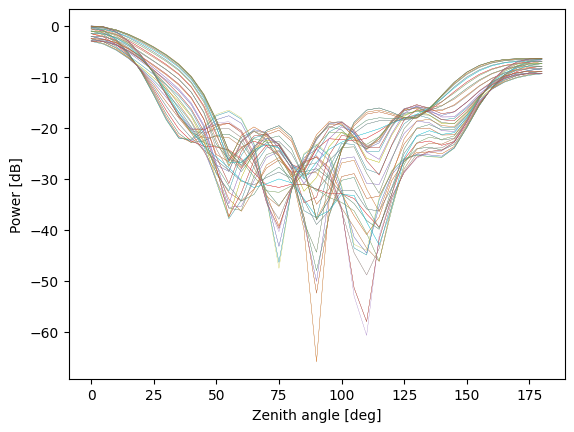

In [88]:
plot_dropoff("6475_3.uan", save_to="dropoff_6475")


BCF stats: {'rms': 0.0007658891264092125, 'swing': 0.0017907716936355067, 'max_abs_deriv': 0.00014255840947243747}


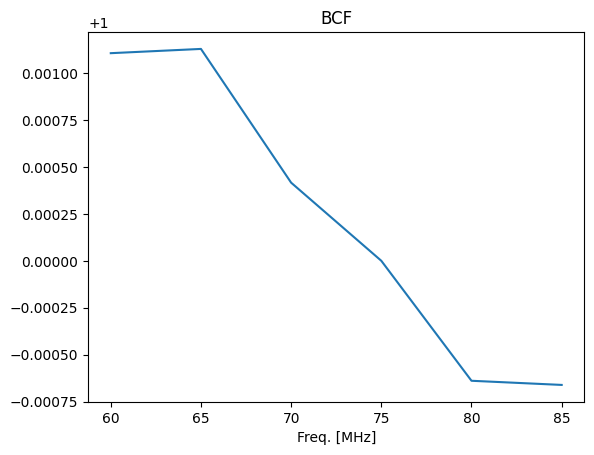

In [73]:
do_bcf_run("6475", "bcf_6475")

6475_1.uan power range in dB -54.14753992278516 -0.3573605550728365
6475_2.uan power range in dB -52.98100555936028 -0.38042493632415186
6475_3.uan power range in dB -42.376808526839454 -0.2742071368170833
6475_4.uan power range in dB -51.62698250441109 -0.33814092633646287
6475_5.uan power range in dB -58.864348348226684 -0.3290019544639512
6475_6.uan power range in dB -50.1886806809318 -0.35555468629789644


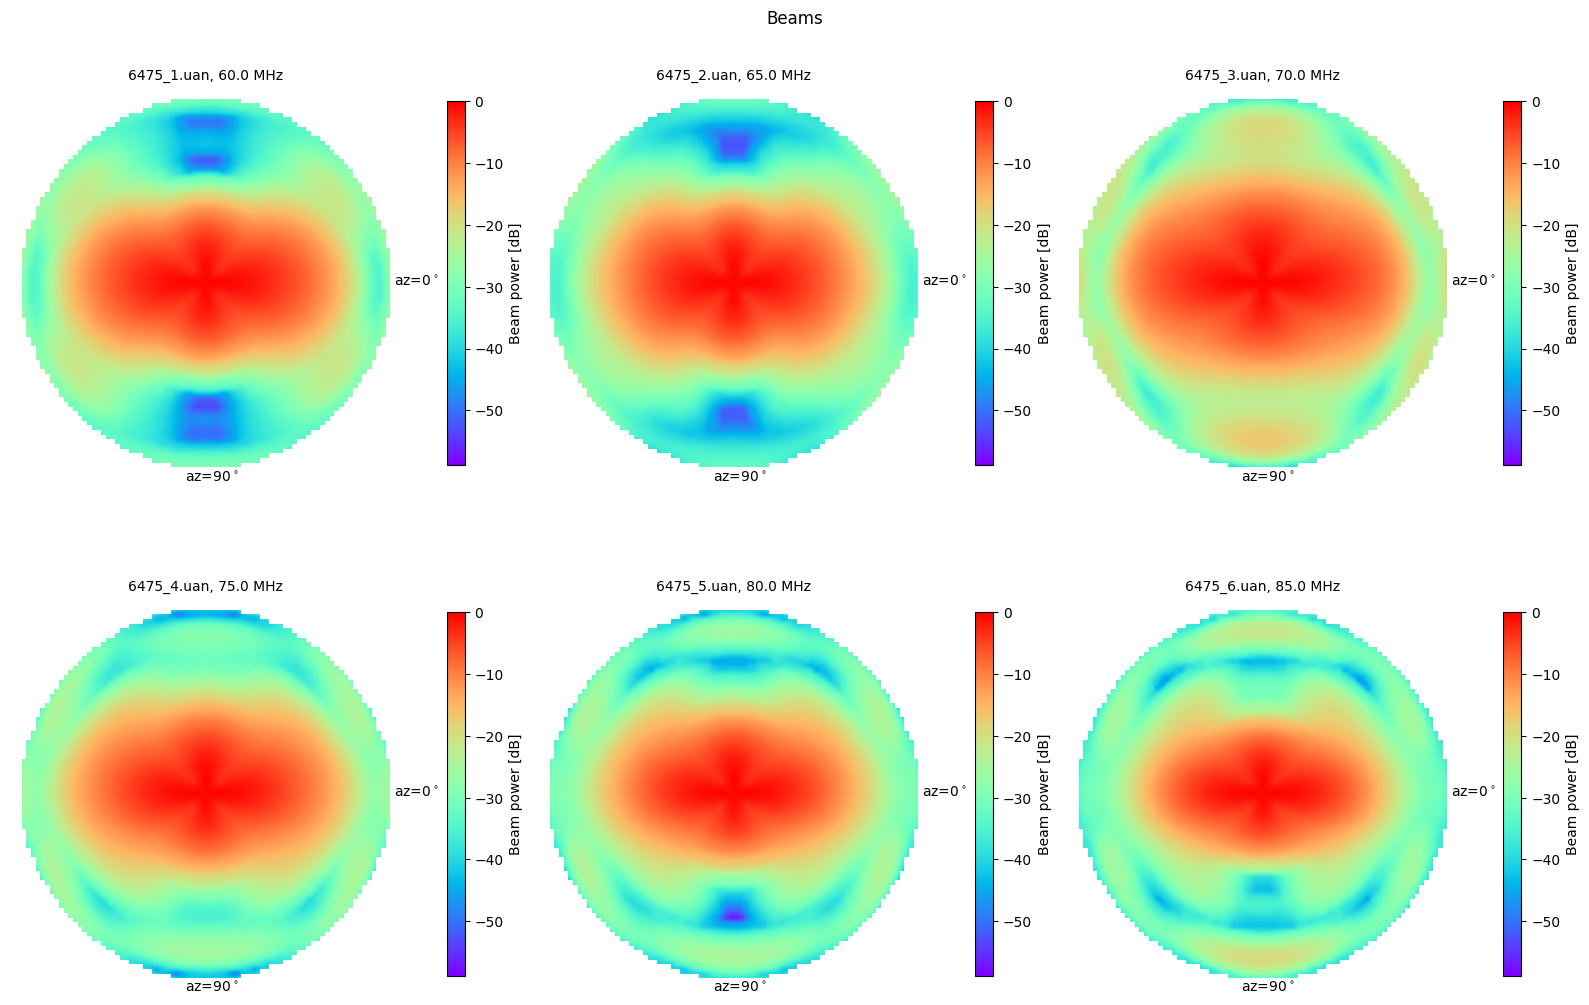

In [74]:
plot_all("6475", 1)

6475_1.uan power range in dB -54.22110599999222 -3.010296042427644
6475_2.uan power range in dB -52.56121199997898 -3.0103009851599327
6475_3.uan power range in dB -47.532277999991884 -3.0102993988717195
6475_4.uan power range in dB -59.20665059997056 -3.0102995486492223
6475_5.uan power range in dB -70.91412519907823 -3.0103031932098863
6475_6.uan power range in dB -57.081618149702194 -3.0103000404861016


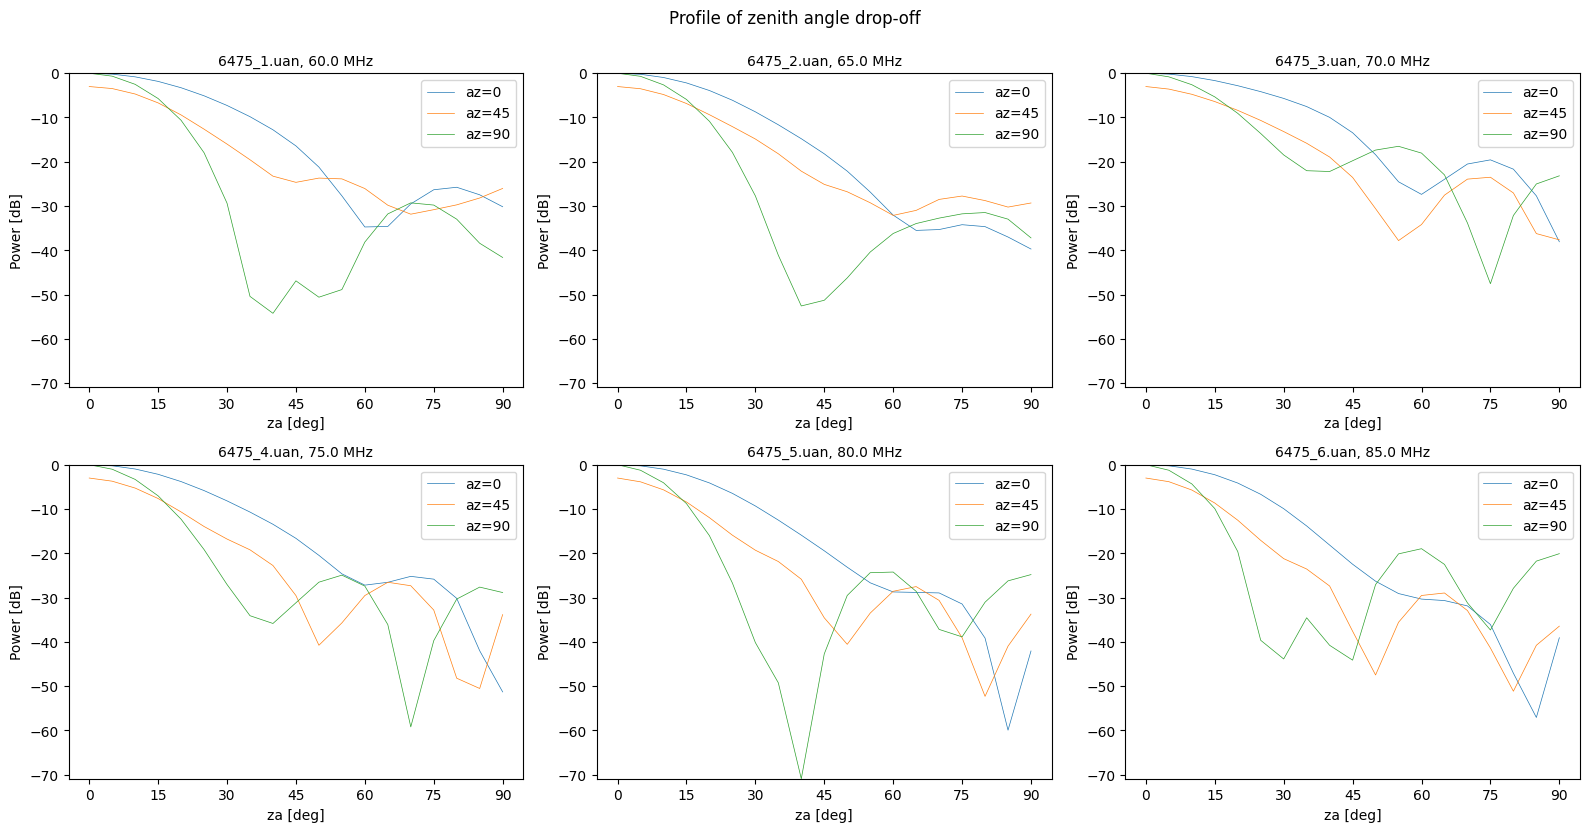

In [75]:
plot_all("6475", 2)

6475_1.uan power range in dB -54.47787007012203 0.0
6475_2.uan power range in dB -53.245591999927186 0.0
6475_3.uan power range in dB -65.89462070047813 0.0
6475_4.uan power range in dB -96.71403057394265 0.0
6475_5.uan power range in dB -70.91412519907823 0.0
6475_6.uan power range in dB -57.09332139109272 0.0


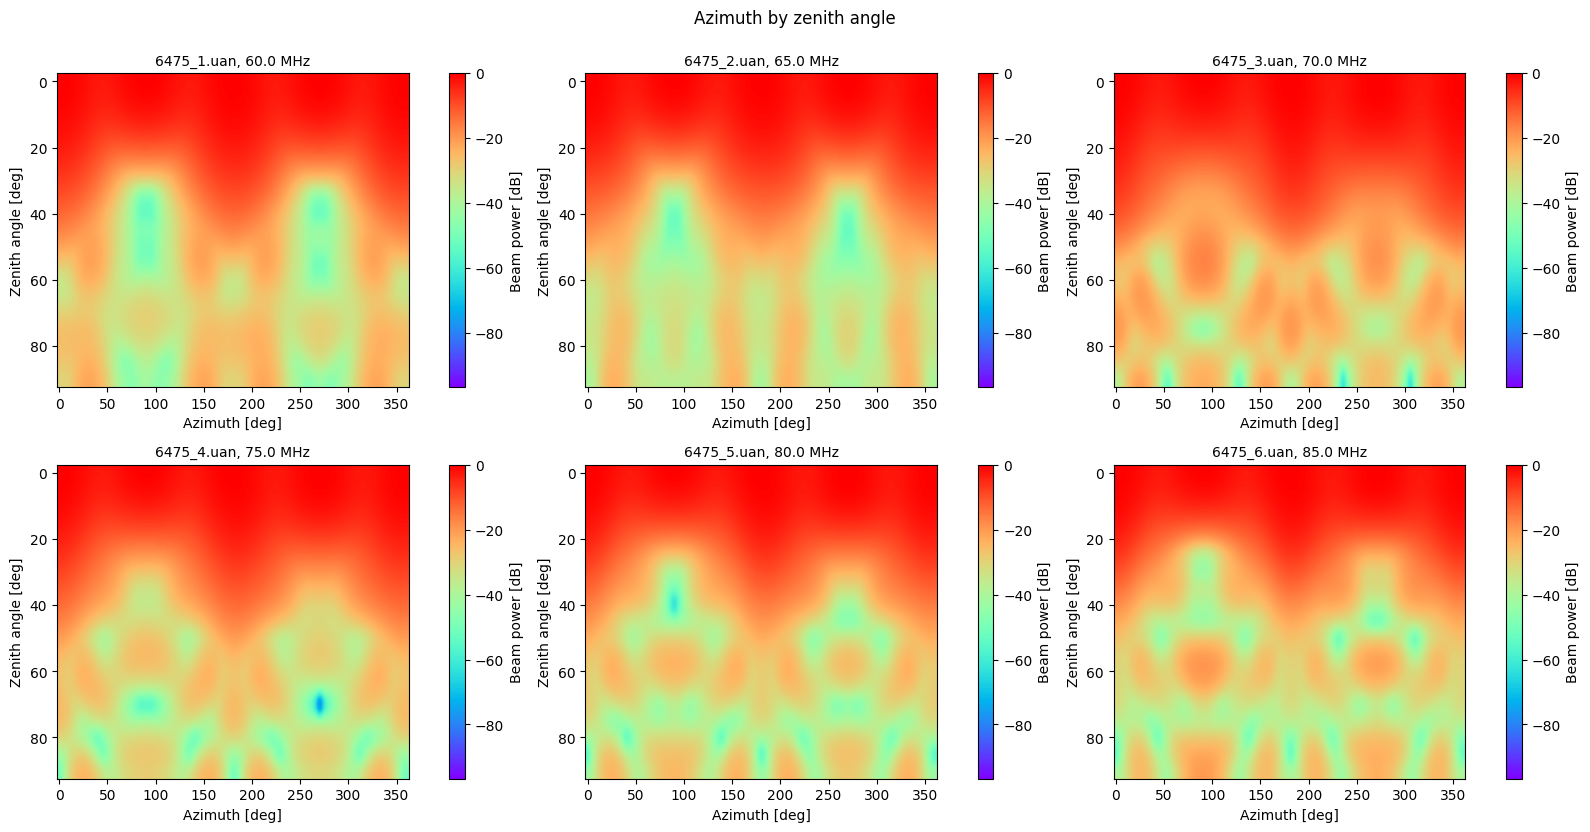

In [76]:
plot_all("6475", 3)

## 24330 BCF and plots

### BCF


BCF stats: {'rms': 0.0021168456401768967, 'swing': 0.003934621499683488, 'max_abs_deriv': 0.0007869242999366977}


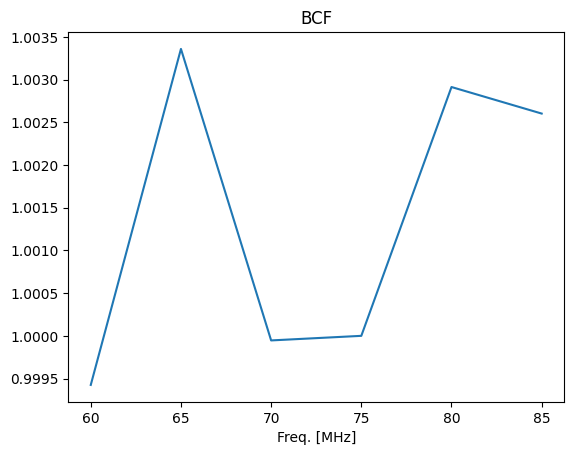

In [77]:
do_bcf_run("24330")

24330_1.uan power range in dB -74.07232711928944 -0.5163422109781411
24330_2.uan power range in dB -69.68330107977553 -0.5204653811459071
24330_3.uan power range in dB -68.96543132681464 -0.534397246762959
24330_4.uan power range in dB -80.9290040809401 -0.5385971228292883
24330_5.uan power range in dB -75.52330009882171 -0.5432874730485735
24330_6.uan power range in dB -72.23729158324926 -0.5475923415733


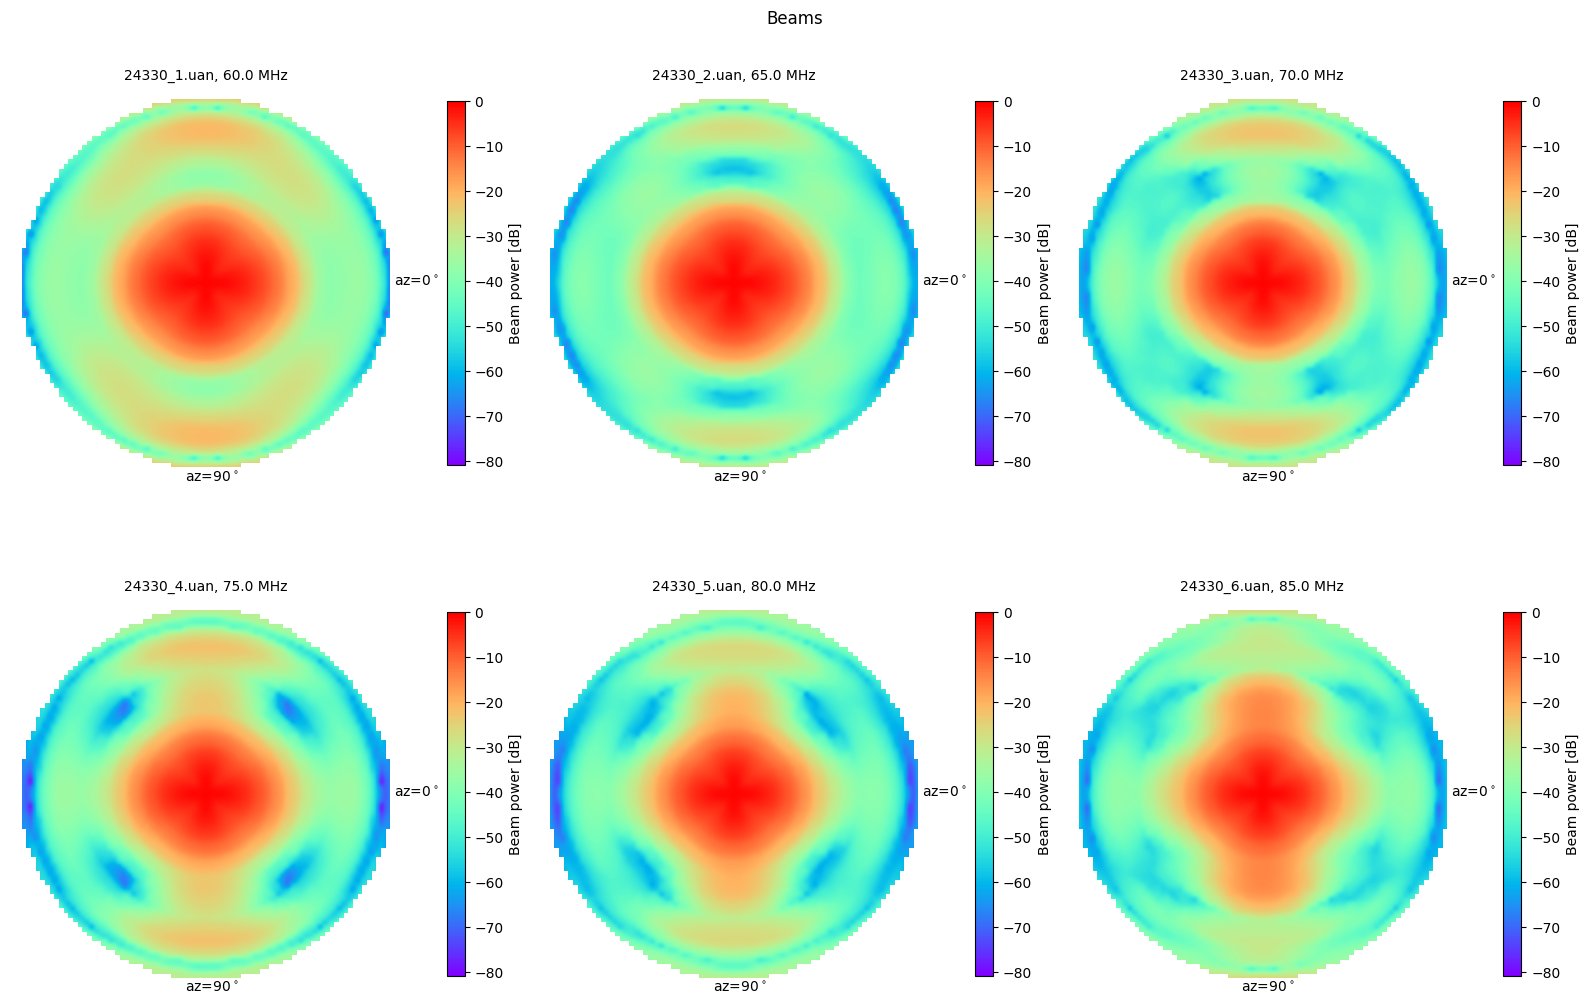

In [78]:
plot_all("24330", 1)

24330_1.uan power range in dB -74.53330799969649 -3.010300043348675
24330_2.uan power range in dB -69.8771479999994 -3.010300043330714
24330_3.uan power range in dB -66.57651999982085 -3.010293043334284
24330_4.uan power range in dB -107.40219735092545 -3.0103080433528167
24330_5.uan power range in dB -76.95213999932234 -3.0103000433597256
24330_6.uan power range in dB -72.20996199085862 -3.0102990433591525


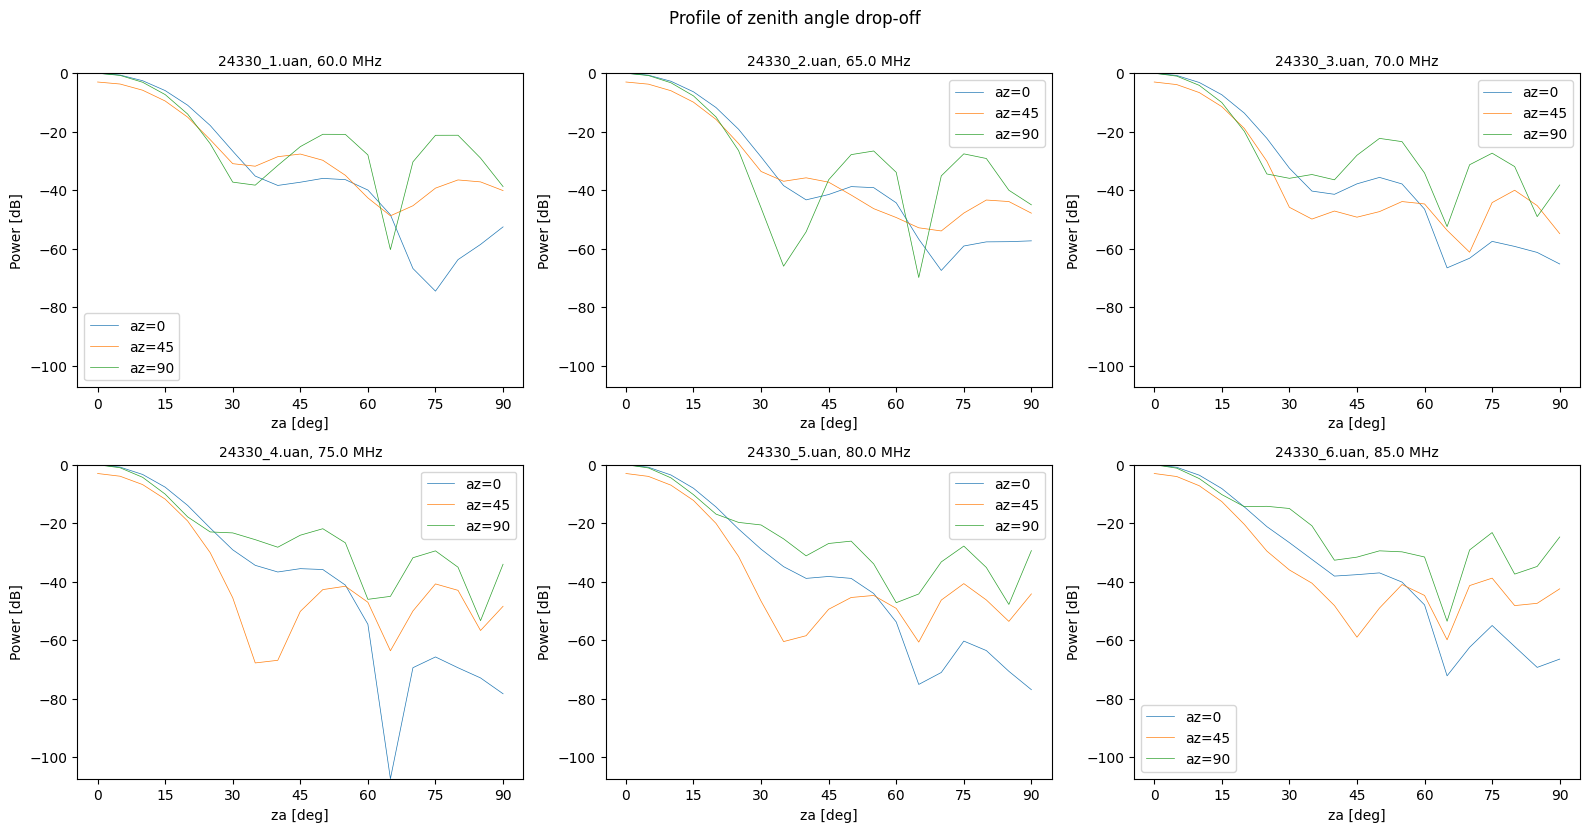

In [79]:
plot_all("24330", 2)

24330_1.uan power range in dB -82.23122615613774 0.0
24330_2.uan power range in dB -71.85749129194033 0.0
24330_3.uan power range in dB -73.21354481836644 0.0
24330_4.uan power range in dB -108.03649702263442 0.0
24330_5.uan power range in dB -76.95213999932234 0.0
24330_6.uan power range in dB -76.79746546811981 0.0


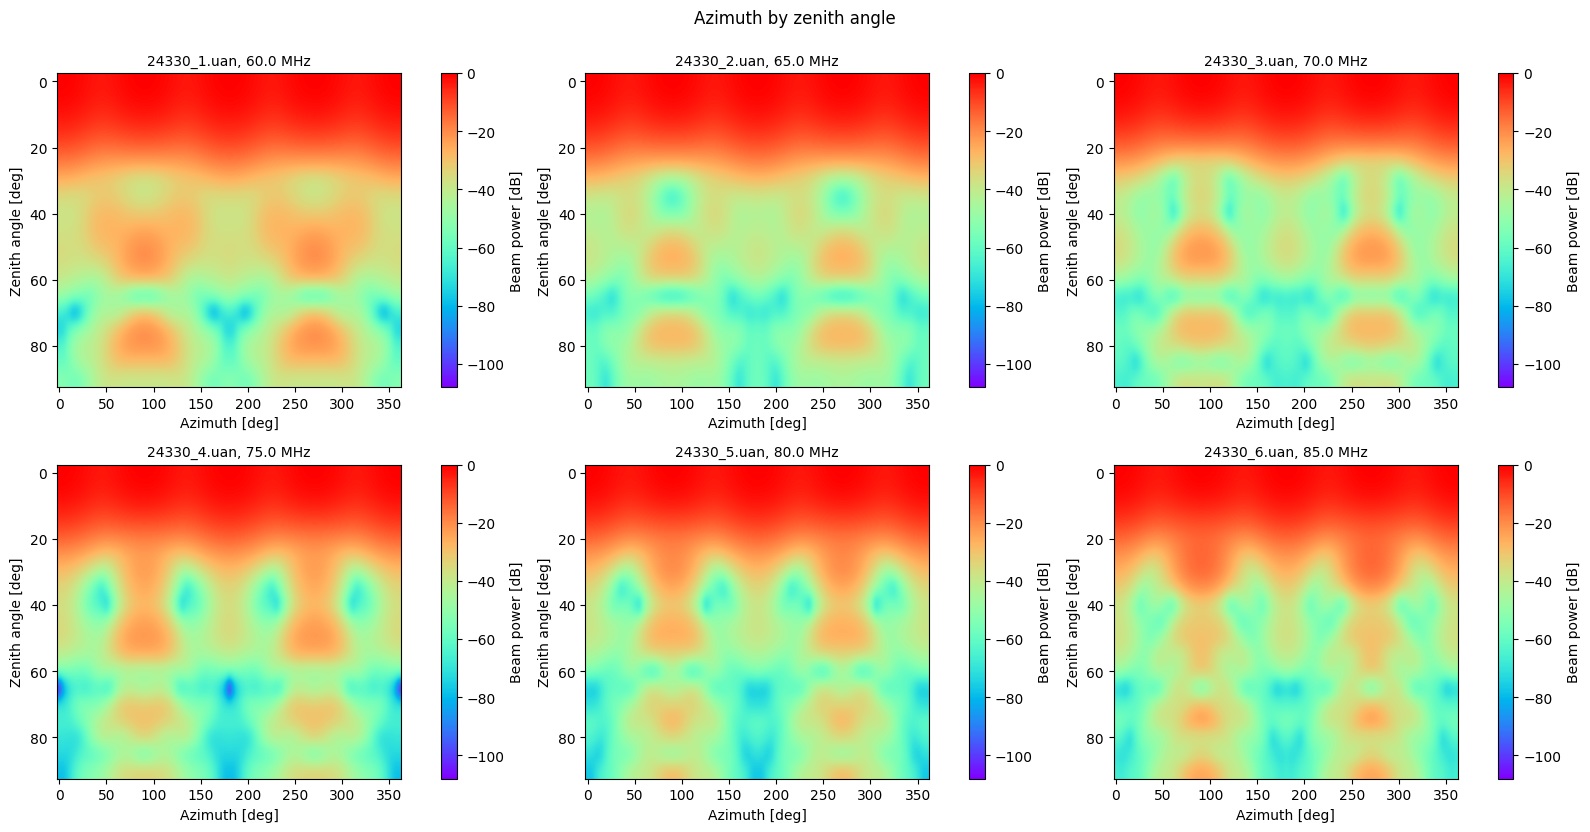

In [80]:
plot_all("24330", 3)

### Combines the above by beam
Disabled. I decided to do it the first way.
